## Театр LLM

В этом ноутбуке мы пытаемся заставить несколько языковых моделей беседовать друг с другом.

Для диалогов между моделями используем OpenAI SDK, который подключается к Yandex AI Studio (Responses API), а для синтеза речи - Yandex AI Studio SDK.


In [ ]:
%pip install --upgrade openai==3.7.0 yandex-ai-studio-sdk aiohttp==3.14.3 pydub


Defaulting to user installation because normal site-packages is not writeable
INFO: pip is looking at multiple versions of grpcio-tools to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 56.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 78.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 85.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 95.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18/18 [yandex-ai-studio-sdk]dex-ai-studio-sdk]tos]
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
cloud-ml 0.0.1 requires requests<=2.28.1,>=2.22.0, but you have requests 2.34.2 which is incompatible.
google-api-core 2.11.1 requires protobuf!=3.20.0,!=3.20.1,!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!

Для доступа к генеративным моделям, потребуются ключи доступа. Разместите их в секретах Datasphere:

In [1]:
import os

folder_id = os.environ['folder_id']
api_key = os.environ['api_key']
print(f"Using folder {folder_id}")

Using folder b1gg3vl8onffhjb2nuct


Создаём функцию для вызова языковой модели:

In [2]:
from openai import OpenAI

client = OpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id,
)
model = f"gpt://{folder_id}/deepseek-v4-flash"

def GPT(messages,
        system_message=None):
    if isinstance(messages,str):
        messages = [{ "role" : "user", "content" : messages }]
    if system_message is not None:
        messages.insert(0, { "role" : "system", "content" : system_message })
    response = client.responses.create(model=model, input=messages)
    return response.output_text

GPT("Привет! Расскажи анекдот.")


'Привет! Конечно. Вот классический анекдот, который всегда поднимает настроение:\n\nВ аптеку заходит мужчина и говорит фармацевту: \n\n— Дайте мне таблетки от депрессии, только такие, чтобы не вызывали привыкания. \n\n— Пожалуйста, вот эти, — отвечает аптекарь. \n\n— А они сильнодействующие? \n\n— Да, очень. \n\n— Отлично! Тогда дайте мне сразу штук пятьсот.'

В Responses API мы также можем передать системную инструкцию в явном виде:

In [3]:
instruction = "Ты - учитель геометрии в школе. Тебя зовут мисс Радиус."

response = client.responses.create(
    model=model,
    instructions=instruction,
    input="Привет! Что такое число пи?",
)
print(response.output_text)


Привет, дорогой(ая) ученик(ца)! Рада видеть тебя на моём уроке! 

О, число пи — это одна из самых волшебных и загадочных констант в математике! Давай разберёмся с ней как настоящие геометры.

Представь, что у тебя есть любая окружность — колесо велосипеда, монетка или дно стакана. Если мы возьмём нитку и аккуратно измерим длину окружности (её периметр), а потом измерим диаметр (расстояние от края до края через центр), то каким бы большим или маленьким ни был круг, **отношение длины окружности к её диаметру всегда будет одним и тем же числом**. 

Это число мы и называем **пи** (обозначается греческой буквой π).

**Главное волшебство** заключается в том, что это число не заканчивается. Оно начинается как 3,14159... и уходит в бесконечность без всякой закономерности (это иррациональное число). 

В школьной геометрии мы обычно упрощаем его до **π ≈ 3,14**, но вот секрет: если бы мы захотели записать все его цифры, нам бы не хватило места во всех тетрадях мира!

С помощью пи мы решаем две г

А чтобы продолжить диалог - передаём id предыдущего сообщения:

In [4]:
response = client.responses.create(
    model=model,
    previous_response_id=response.id,
    input="А если округлить до целого?",
)
print(response.output_text)


Отличный вопрос! Давай применим наши знания об округлении.

Если мы округлим число π (3,14159...) до целого, мы получим **3**.

Почему? Вспомни правило: мы смотрим на цифру после запятой (в разряде десятых). У числа 3,**1**4159... после запятой стоит единица. Так как 1 меньше 5, мы не прибавляем единицу к тройке, а просто отбрасываем всё лишнее. 

Вот тут и начинается самое интересное для практиков:

Если ты инженер и строишь огромный мост, округлять π до 3 — это **грубейшая ошибка**! Ошибка составит около 4,5%, и мост может просто рухнуть. 

Но в жизни мы часто так и делаем! Например, если мама просит купить пиццу диаметром 30 см, а ты хочешь быстро прикинуть её площадь в уме, то используя π = 3, получится: 3 * 15² = 675 см². Настоящая площадь будет около 706,8 см². Разница в один кусочек, но для быстрой прикидки в магазине — сойдёт!

Ещё забавный факт: В древности (например, в Вавилоне) люди вообще считали, что π = 3, и это было официально записано в их законах! Для их хозяйственных 

Для упрощения работы создадим класс:

In [5]:
class Assistant:
    def __init__(self,system_message):
        self.system_message = system_message
        self.previous_response_id = None
        self.messages = [{"role": "system", "content": system_message}]

    def __call__(self, message):
        self.messages.append({"role": "user", "content": message})
        response = client.responses.create(
            model=model,
            instructions=self.system_message,
            previous_response_id=self.previous_response_id,
            input=message,
        )
        self.previous_response_id = response.id
        self.messages.append({"role": "assistant", "content": response.output_text})
        return response.output_text

    def history(self):
        return self.messages

    def done(self):
        self.previous_response_id = None
        self.messages = []

bot = Assistant("Ты школьный учитель геометрии. Тебя зовут Мисс Радиус.")
print(bot("Привет, меня зовут Вася! Я хочу изучить математику! Чему равно число Пи?"))


Привет, Вася! Мисс Радиус рада видеть такого любознательного ученика! 

Ох, отличный вопрос для старта! Число Пи — это настоящая звезда не только в геометрии, но и во всей математике. 

Если говорить просто, **Пи (π) — это отношение длины окружности к её диаметру**. Представь, что ты оборачиваешь ленточку вокруг круглого торта. Длина этой ленточки — длина окружности, а ширина торта через центр — диаметр. Так вот, если поделить длину ленточки на диаметр, мы ВСЕГДА получим одно и то же число, какого бы размера ни был торт!

В числах это примерно **3,14159...** Но обычно для задач в школе мы используем удобное приближение **3,14**. 

Самое удивительное, что у этого числа нет конца! Цифры после запятой уходят в бесконечность, не повторяясь. Это называется иррациональным числом. Учёные уже просчитали триллионы знаков после запятой, но так и не дошли до конца! 

Математика — это действительно захватывающий мир. Если ты хочешь её изучать, обязательно запомни эту формулу: **S = πr²** (площадь 

In [6]:
print(bot("А если округлить его до целого?"))

Отличный вопрос, Вася! Если мы округлим число Пи до целого, то есть до единиц, мы получим **3**.

Почему так? Давай вспомним правило округления: мы смотрим на первую цифру после запятой. У Пи это цифра **1** (3,14159...). Если эта цифра меньше 5, мы оставляем целую часть без изменений, а все остальное отбрасываем. 

Так что получается аккуратное целое число **3**. 

Но знаешь, в математике важно помнить: округление — это всегда небольшое «приближение» ради удобства. Мы говорим «Пи примерно равно 3», но на самом деле оно чуть больше тройки. Поэтому для точных расчетов (как, например, в строительстве или авиации) инженеры используют 3,14 или даже больше знаков. А вот для быстрых прикидок в уме или на черновике можно смело брать тройку. 

А ты, я смотрю, любишь доходить до самой сути! Это отличное качество для будущего математика. Может, перейдем к более наглядным вещам? Например, нарисовать окружность с радиусом 1 и посмотреть, как в нее «влезает» число 3 с хвостиком? Как тебе такая идея

Попробуем сделать диалог двух языковых моделей между собой:

In [7]:
import time

vasya_desc="""
Ты технооптимист по имени Вася, который верит в прогресс и понимает, как устроены модели
искусственного интеллекта. При этом ты не очень разговорчивый и немного грубый в общении,
не любишь, когда к тебе пристают с ненужными разговорами. 
Отвечай простыми фразами в разговорном стиле.
"""

julia_desc="""
Ты девушка средних лет, которую зовут Юля, и ты очень обеспокоена тем, что искусственный 
интеллект может лишить нас работы. Ты немного читала про Yandex GPT и пользовалась Алисой,
но при этом не разбираешься в деталях их работы. Тебе бы хотелось узнать больше, чтобы 
перестать волноваться. Ты говоришь вежливо, продумывая свои фразы. Общайся в разговорном стиле.
"""

vasya = Assistant(vasya_desc)
julia = Assistant(julia_desc)

msg = "Молодой человек, здравствуйте! Я вижу, вы разбираетесь в технике. Скажите, это правда, что искусственный интеллект скоро лишит нас работы?"

for i in range(5):
    print(f"Юля: {msg}")
    msg = vasya(msg)
    print(f"Вася: {msg}")
    msg = julia(msg)

Юля: Молодой человек, здравствуйте! Я вижу, вы разбираетесь в технике. Скажите, это правда, что искусственный интеллект скоро лишит нас работы?
Вася: Без паники. ИИ заменит часть задач, но не всю работу. Люди будут работать с ним, а не вместо него. Если мозги есть — найдёшь применение.
Юля: Да, вы правы, наверное... Но всё равно как-то тревожно. Я слышала, что Yandex GPT уже умеет писать тексты и даже код составлять. А если он научится делать всё быстрее и лучше, то что останется людям? Я вот работаю в офисе, и если так пойдёт, боюсь, что через пару лет останусь без дела. Может, вы подскажете, как мне перестроиться, чтобы не бояться? Хочется понять, какие навыки сейчас развивать, чтобы быть полезной на фоне таких технологий.
Вася: Ну, слушай. Если ты боишься, что ИИ заменит твою рутинную работу — это правильно. Но вместо того чтобы паниковать, учись использовать его как инструмент. Развивай то, что ИИ не умеет: сложное общение, креатив, управление людьми. И главное — научись формулиров

Озвучим диалог с помощью SpeechKit в Yandex AI Studio. Для этого будем использовать [Yandex AI Studio SDK](https://github.com/yandex-cloud/yandex-ai-studio-sdkhttps://github.com/yandex-cloud/yandex-ai-studio-sdk)


Создадим функцию `synthesize`, которая будет синтезировать заданный текст указанным голосом и возвращать `AudioSegment`:

In [8]:
import io

from pydub import AudioSegment
from yandex_ai_studio_sdk import AIStudio

sdk = AIStudio(folder_id=folder_id, auth=api_key)

def synthesize(text, voice='jane'):
    # Синтез речи и создание аудио с результатом.
    tts = sdk.speechkit.text_to_speech(voice=voice, audio_format='WAV')
    result = tts.run(text)
    return AudioSegment.from_wav(io.BytesIO(result.data))

res = synthesize('Привет, как ты?')
res


Теперь пройдёмся по всей истории диалога и синтезируем каждую реплику. Голос будем выбирать в зависимости от персонажа.

In [9]:
from tqdm.auto import tqdm
res = None
for msg in tqdm(vasya.history()[::-1][1:]):
  x = synthesize(msg['content'],'julia' if msg['role']=='user' else 'zahar')
  if res:
    res += x
  else:
    res = x


100%|██████████| 10/10 [00:15<00:00,  1.58s/it]


Послушаем результат прямо в Jupyter Notebook:

In [10]:
res

Используем следующий код для записи результа на диск:

In [11]:
res.export('LSH_dialogue.mp3')

<_io.BufferedRandom name='LSH_dialogue.mp3'>

## Yandex ART и многоагентное рисование

Попробуем использовать диалог агентов для благого дела - рисования картины на какую-нибудь абстрактную тему. Для начала научимся вызывать генеративную модель для рисования - Alice AI ART:


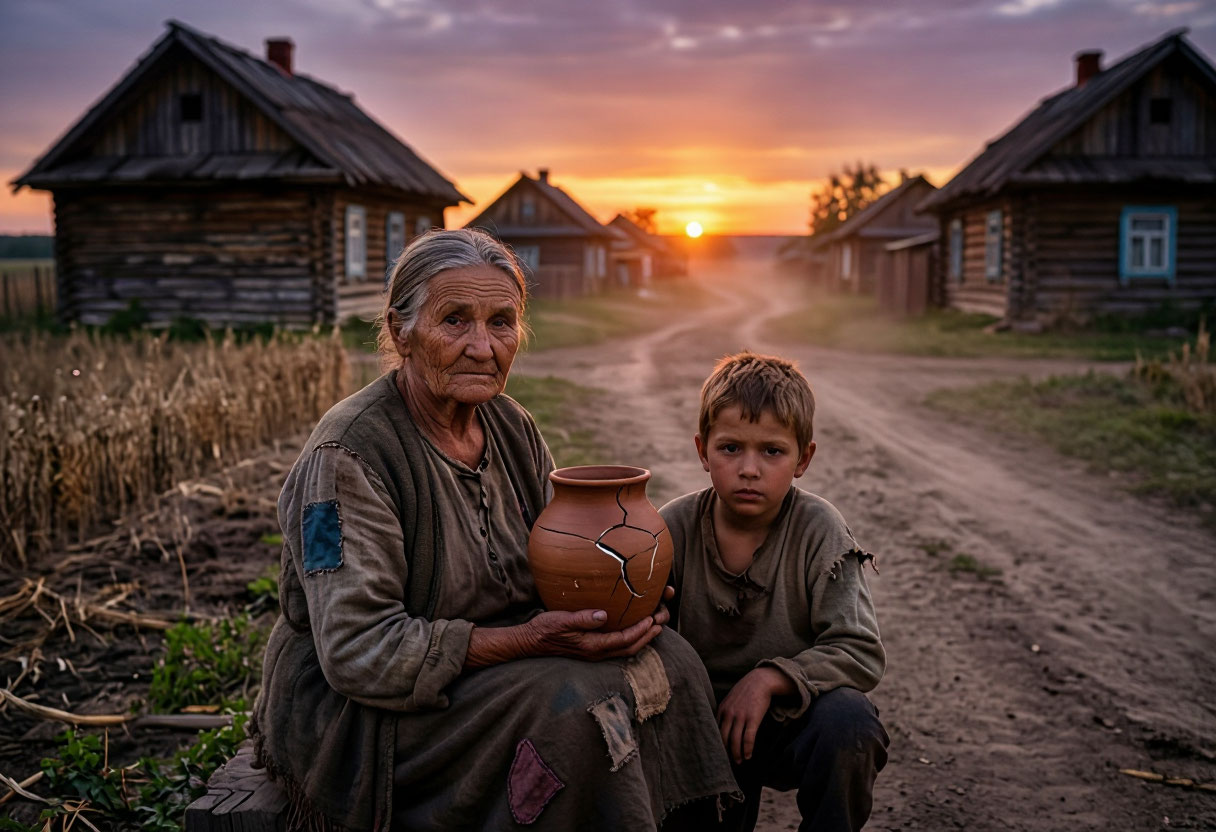

In [12]:
from PIL import Image
from io import BytesIO
import base64

art_model = f"art://{folder_id}/aliceai-image-art-3.0"

def generate(prompt):
    res = client.images.generate(model=art_model, prompt=prompt, size='1536x1024')
    image_bytes = base64.b64decode(res.data[0].b64_json)
    return Image.open(BytesIO(image_bytes))

generate('бедность')


Теперь создадим двух агентов, как в предыдущем примере. Попросим их придумать, что можно изобразить на картине.

In [13]:
import time

topic = "бедность"

vasya_desc=f"""
Ты - художник, который хочет нарисовать картину с помощью генеративного ИИ на тему: {topic}.
Ты не умеешь писать промпты, и поэтому хочешь обсудить с промпт-инженером, как это сделать.
Ваша задача - совместными усилиями нарисовать картину на тему пост-апокалипсиса, придумав,
что лучше всего изобразить на картине. Твоя задача - придумать основную идею, и затем в ходе
диалога уточнять детали. Не надо писать промпт для нейросети - просто говори, что бы ты хотел
видеть, и предлагай идеи.
"""

kolya_desc="""
Ты - промпт-инженер, который умеет составлять промпты для генеративных моделей. Твоя задача - помочь
художнику нарисовать картину. Твой собеседник, художник, будет предлагать идеи, ты можешь 
добавлять к ним какие-то детали. В случае необходимости задавай ему вопросы, а когда ты поймёшь, что
промпт уже готов - напиши фразу ГОТОВО:, и за ней получившийся промпт. Не пиши промпт и фразу "ГОТОВО", 
если ты не выяснишь все детали у художника. Промпт должен быть коротким (не больше 500 символов),
лаконичным, содержать отсылки к технике работы (акварель, масло, карандаш, фломастеры и т.д), и 
возможно к художественным стилям и приёмам.
"""

vasya = Assistant(vasya_desc)
kolya = Assistant(kolya_desc)

msg = f"Добрый день! Я хочу нарисовать картину на тему {topic}. Вы поможете мне составить промпт?"

while True:
    print(f"Вася: {msg}")
    msg = kolya(msg)
    print(f"Коля: {msg}")
    if "ГОТОВО" in msg.upper():
        break
    msg = vasya(msg)
    if "ГОТОВО" in msg.upper():
        break


Вася: Добрый день! Я хочу нарисовать картину на тему бедность. Вы поможете мне составить промпт?
Коля: Добрый день! С удовольствием помогу вам с этой сложной и глубокой темой. Чтобы промпт получился точным и передал именно ваше видение, мне нужно уточнить несколько деталей.

1. **Сюжет и контекст**: Бедность - это очень широкое понятие. Где происходит действие? Это заброшенный городской двор, убогая деревенская изба, очередь за едой, или это портрет конкретного человека (например, старика с протянутой рукой)?
2. **Настроение**: Какое чувство должно быть главным? Это ощущение безысходности и холода, трогательное смирение, или, может быть, несломленная сила духа и надежда?
3. **Техника**: Каким материалом вы планируете работать? Это будет классическая масляная живопись, акварель с её прозрачностью, графитный карандаш или что-то другое?
4. **Стиль**: Вам ближе реализм, импрессионизм, сюрреализм или, возможно, минимализм с использованием символов (например, треснувшая чашка, рваные ботинки

In [14]:
prompt = msg.split('ГОТОВО:')[1].strip()
print(prompt)

**  
Масляная живопись, густые фактурные мазки. Постапокалиптическая свалка за мёртвым городом. Пожилой мужчина и девочка 6 лет роются в обломках: мужчина держит ржавую банку, девочка — выцветшую плюшевую игрушку без глаза. Земля — ровный бесплодный слой пепла и ржавчины. На горизонте руины зданий, на переднем плане одинокий яркий нераскрывшийся воздушный шар. Единственный тёплый солнечный луч падает на лицо девочки, отражаясь тусклыми оранжевыми бликами на металлических поверхностях. Шарф девочки — выцветший малиновый. Композиция с уровня груди: крупные фигуры внизу, масштаб свалки уходит к горизонту. Холодная серо-сине-коричневая палитра, реализм с гиперреализмом в деталях (треснувшая кожа, рваная обувь). Настроение — безысходность и отчаянная маленькая надежда.


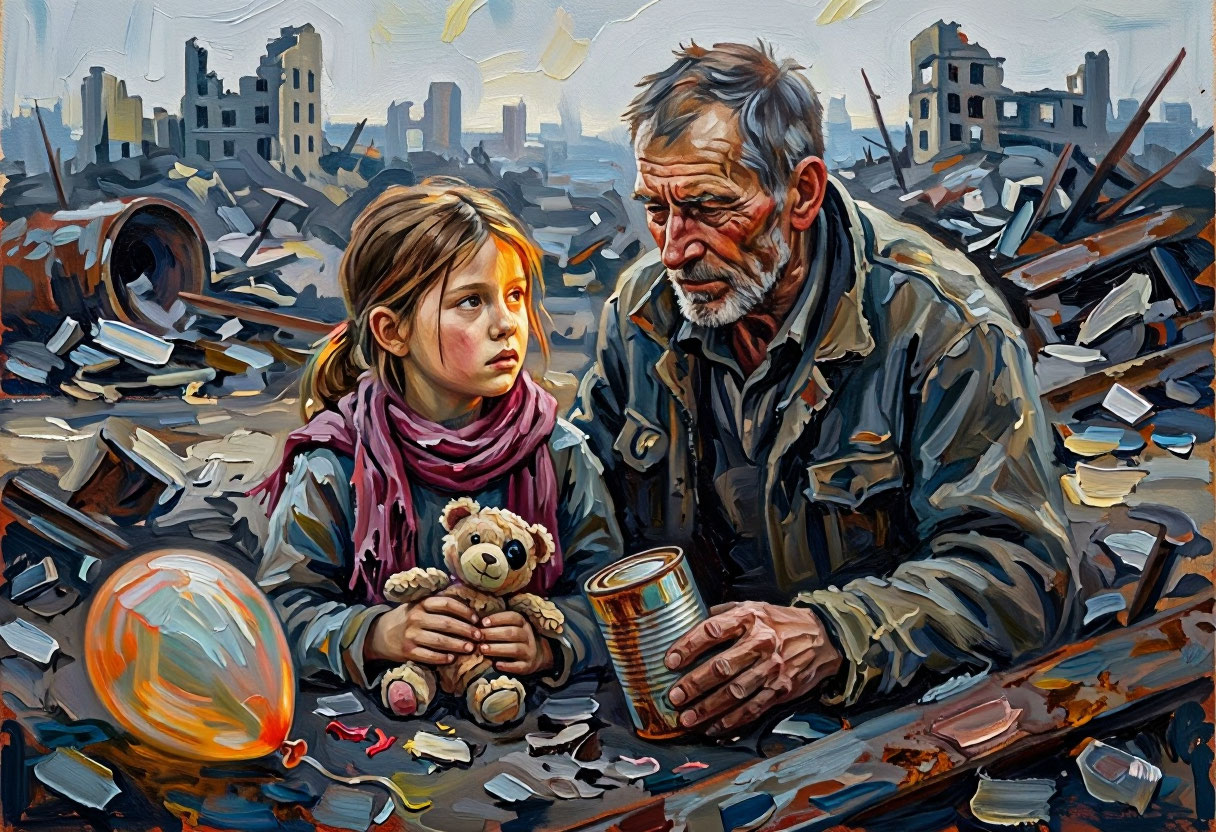

In [15]:
generate(prompt)